In [2]:
# import libraries
import time
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from arch import arch_model

In [2]:
# ==============================================================================
# Environment Setup
# ==============================================================================
# %pip install arch
# Why use %pip instead of !pip or the terminal?
# The %pip magic directive ensures that the installation happens strictly 
# within the exact environment/executable where the Notebook Kernel is 
# currently running, eliminating any path errors.

In [3]:
# ==============================================================================
# 1. Data Collection and Preparation
# ==============================================================================
def fetch_clean_series(ticker: str, start_date: str = "2021-01-01", max_retries: int = 3) -> pd.Series:
    """
    Fetches historical closing prices for a given ticker with a retry mechanism.

    Args:
        ticker (str): The financial asset's ticker symbol.
        start_date (str, optional): The start date for the data download (YYYY-MM-DD). Defaults to "2021-01-01".
        max_retries (int, optional): Maximum number of attempts if the download fails. Defaults to 3.

    Returns:
        pd.Series: A pandas Series containing the cleaned closing prices without missing values.

    Raises:
        RuntimeError: If the data cannot be downloaded after the maximum number of retries.
    """
    for attempt in range(max_retries):
        try:
            data = yf.download(ticker, start=start_date, progress=False, auto_adjust=False)
            if not data.empty:
                if isinstance(data.columns, pd.MultiIndex):
                    series = data["Close"][ticker]
                else:
                    series = data["Close"]
                return series.dropna()
        except Exception as e:
            print(f"[{ticker}] Error on attempt {attempt + 1}: {e}")
        time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"Failed to download {ticker}.")

def prepare_returns_pair(ticker_a: str, ticker_b: str, label_a: str, label_b: str, start_date: str = "2021-01-01"):
    """
    Downloads and synchronizes time series for a pair of assets, calculating logarithmic returns.

    Args:
        ticker_a (str): Ticker symbol for the first asset.
        ticker_b (str): Ticker symbol for the second asset.
        label_a (str): Descriptive label for the first asset.
        label_b (str): Descriptive label for the second asset.
        start_date (str, optional): The start date for the data download. Defaults to "2021-01-01".

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: Synchronized daily prices for both assets.
            - pd.DataFrame: Synchronized daily logarithmic returns (multiplied by 100).
    """
    s_a = fetch_clean_series(ticker_a, start_date)
    time.sleep(1.5)
    s_b = fetch_clean_series(ticker_b, start_date)
    
    df_prices = pd.DataFrame({label_a: s_a, label_b: s_b}).dropna()
    # Logarithmic returns multiplied by 100 for GARCH numerical stability
    returns = (np.log(df_prices / df_prices.shift(1)).dropna()) * 100
    return df_prices, returns

# ==============================================================================
# 2. Correlation Estimation Methods
# ==============================================================================
def compute_rolling_corr(returns: pd.DataFrame, col_a: str, col_b: str, window: int = 60) -> pd.Series:
    """
    Computes the classic Pearson correlation using a uniform rolling window.

    Args:
        returns (pd.DataFrame): DataFrame containing the asset returns.
        col_a (str): Column name for the first asset.
        col_b (str): Column name for the second asset.
        window (int, optional): Number of periods for the rolling window. Defaults to 60.

    Returns:
        pd.Series: A pandas Series representing the rolling correlation over time.
    """
    return returns[col_a].rolling(window=window).corr(returns[col_b])

def compute_ewma_corr(returns: pd.DataFrame, col_a: str, col_b: str, decay: float = 0.94) -> pd.Series:
    """
    Computes the Exponentially Weighted Moving Average (EWMA) correlation (RiskMetrics).

    Args:
        returns (pd.DataFrame): DataFrame containing the asset returns.
        col_a (str): Column name for the first asset.
        col_b (str): Column name for the second asset.
        decay (float, optional): The decay factor (lambda). Defaults to 0.94.

    Returns:
        pd.Series: A pandas Series representing the EWMA dynamic correlation.
    """
    r1 = returns[col_a]
    r2 = returns[col_b]
    
    cov_12 = r1.ewm(alpha=1 - decay).cov(r2)
    var_1 = r1.ewm(alpha=1 - decay).var()
    var_2 = r2.ewm(alpha=1 - decay).var()
    
    return cov_12 / np.sqrt(var_1 * var_2)

def fit_dcc_garch(returns: pd.DataFrame, col_a: str, col_b: str) -> pd.Series:
    """
    Estimates the Dynamic Conditional Correlation (DCC-GARCH).

    Methodology:
        Step 1: Fits a univariate GARCH(1,1) model to each series and extracts standardized residuals.
        Step 2: Optimizes the DCC parameters (alpha and beta) via Maximum Likelihood Estimation.

    Args:
        returns (pd.DataFrame): DataFrame containing the asset returns.
        col_a (str): Column name for the first asset.
        col_b (str): Column name for the second asset.

    Returns:
        pd.Series: A pandas Series representing the DCC-GARCH conditional correlation.
    """
    r1 = returns[col_a].values
    r2 = returns[col_b].values
    T = len(r1)

    # Step 1: Univariate GARCH(1,1) Fitting
    am1 = arch_model(r1, mean='Zero', vol='GARCH', p=1, q=1, dist='Normal')
    res1 = am1.fit(disp='off')
    std_resid1 = res1.resid / res1.conditional_volatility

    am2 = arch_model(r2, mean='Zero', vol='GARCH', p=1, q=1, dist='Normal')
    res2 = am2.fit(disp='off')
    std_resid2 = res2.resid / res2.conditional_volatility

    eps = np.column_stack([std_resid1, std_resid2])
    Q_bar = np.cov(eps.T)

    # Step 2: DCC Stage Log-Likelihood Function
    def dcc_loglik(params):
        a, b = params
        if a < 0 or b < 0 or (a + b) >= 0.999:
            return 1e10
        
        Q = Q_bar.copy()
        ll = 0.0
        for t in range(T):
            e_prev = eps[t - 1].reshape(-1, 1) if t > 0 else np.zeros((2, 1))
            Q = (1 - a - b) * Q_bar + a * (e_prev @ e_prev.T) + b * Q
            q11 = np.maximum(Q[0, 0], 1e-6)
            q22 = np.maximum(Q[1, 1], 1e-6)
            rho = np.clip(Q[0, 1] / np.sqrt(q11 * q22), -0.9999, 0.9999)
            
            # Gaussian correlation log-likelihood contribution
            det_R = 1 - rho**2
            e_t = eps[t]
            quad_form = (e_t[0]**2 + e_t[1]**2 - 2 * rho * e_t[0] * e_t[1]) / det_R
            ll += 0.5 * (np.log(det_R) + quad_form - (e_t[0]**2 + e_t[1]**2))
            
        return ll

    # Numerical optimization of DCC parameters (alpha and beta)
    init_params = [0.05, 0.90]
    bounds = [(1e-5, 0.3), (0.6, 0.999)]
    opt_res = minimize(dcc_loglik, init_params, bounds=bounds, method='Nelder-Mead')
    a_opt, b_opt = opt_res.x

    # Reconstruction of the conditional correlation series
    dcc_corr = np.zeros(T)
    Q = Q_bar.copy()
    for t in range(T):
        e_prev = eps[t - 1].reshape(-1, 1) if t > 0 else np.zeros((2, 1))
        Q = (1 - a_opt - b_opt) * Q_bar + a_opt * (e_prev @ e_prev.T) + b_opt * Q
        q11 = np.maximum(Q[0, 0], 1e-6)
        q22 = np.maximum(Q[1, 1], 1e-6)
        dcc_corr[t] = np.clip(Q[0, 1] / np.sqrt(q11 * q22), -0.9999, 0.9999)

    return pd.Series(dcc_corr, index=returns.index)

# ==============================================================================
# 3. Comparative Visualization
# ==============================================================================
def plot_models_comparison(
    prices: pd.DataFrame, 
    returns: pd.DataFrame, 
    label_a: str, 
    label_b: str, 
    output_filename: str = "garch_comparison.png"
):
    """
    Generates and saves a two-panel comparative plot showing normalized prices 
    and the different dynamic correlation models.

    Args:
        prices (pd.DataFrame): Synchronized prices dataframe.
        returns (pd.DataFrame): Synchronized returns dataframe.
        label_a (str): Descriptive label for the first asset.
        label_b (str): Descriptive label for the second asset.
        output_filename (str, optional): File path for saving the plot. Defaults to "garch_comparison.png".
    """
    rolling_60 = compute_rolling_corr(returns, label_a, label_b, window=60)
    ewma_corr = compute_ewma_corr(returns, label_a, label_b, decay=0.94)
    dcc_corr = fit_dcc_garch(returns, label_a, label_b)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    # Panel 1: Normalized Prices
    norm_a = (prices[label_a] / prices[label_a].iloc[0]) * 100
    norm_b = (prices[label_b] / prices[label_b].iloc[0]) * 100
    ax1.plot(prices.index, norm_a, label=f"{label_a} (Base 100)", color="#1f77b4", lw=1.5)
    ax1.plot(prices.index, norm_b, label=f"{label_b} (Base 100)", color="#2ca02c", lw=1.5)
    ax1.set_title(f"Normalized Price Dynamics: {label_a} vs. {label_b}", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Normalized Index (Base 100)")
    ax1.legend(loc="upper left")
    ax1.grid(True, linestyle="--", alpha=0.4)

    # Panel 2: Correlation Models Comparison
    ax2.plot(returns.index, rolling_60, label="Rolling Window (60d)", color="#ff7f0e", lw=1.4, linestyle="--")
    ax2.plot(returns.index, ewma_corr, label="EWMA (λ = 0.94)", color="#9467bd", lw=1.2, alpha=0.8)
    ax2.plot(returns.index, dcc_corr, label="DCC-GARCH (1,1)", color="#d62728", lw=1.6)
    
    ax2.axhline(0, color="gray", linestyle=":", alpha=0.7)
    ax2.set_ylabel("Dynamic Correlation")
    ax2.set_title("Methodological Comparison: Rolling vs. EWMA vs. DCC-GARCH", fontsize=11, fontweight="bold")
    ax2.legend(loc="lower left")
    ax2.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig(output_filename, dpi=300)
    print(f"Comparative plot successfully saved: {output_filename}")
    plt.show()



\nProcessing: International parity pass-through vs. corporate/state risk
Comparative plot successfully saved: 01_petr4_vs_brent_garch.png


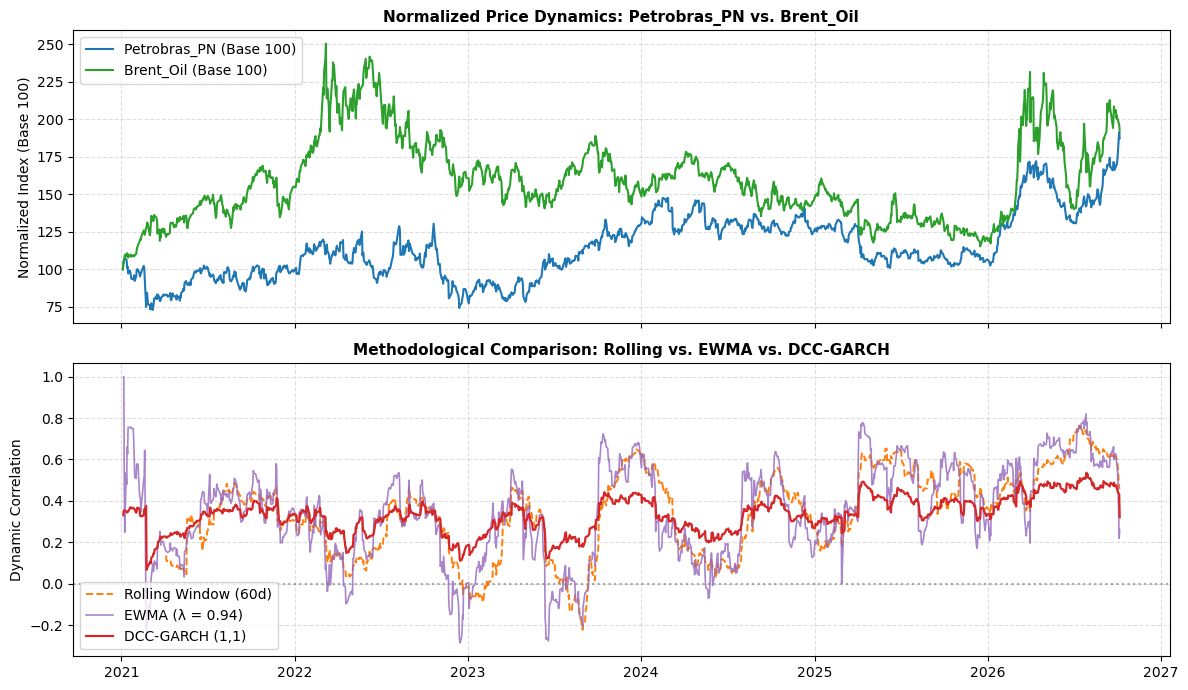

\nProcessing: Stock market sensitivity and foreign flow to harvest yields
Comparative plot successfully saved: 02_ewz_vs_soybean_garch.png


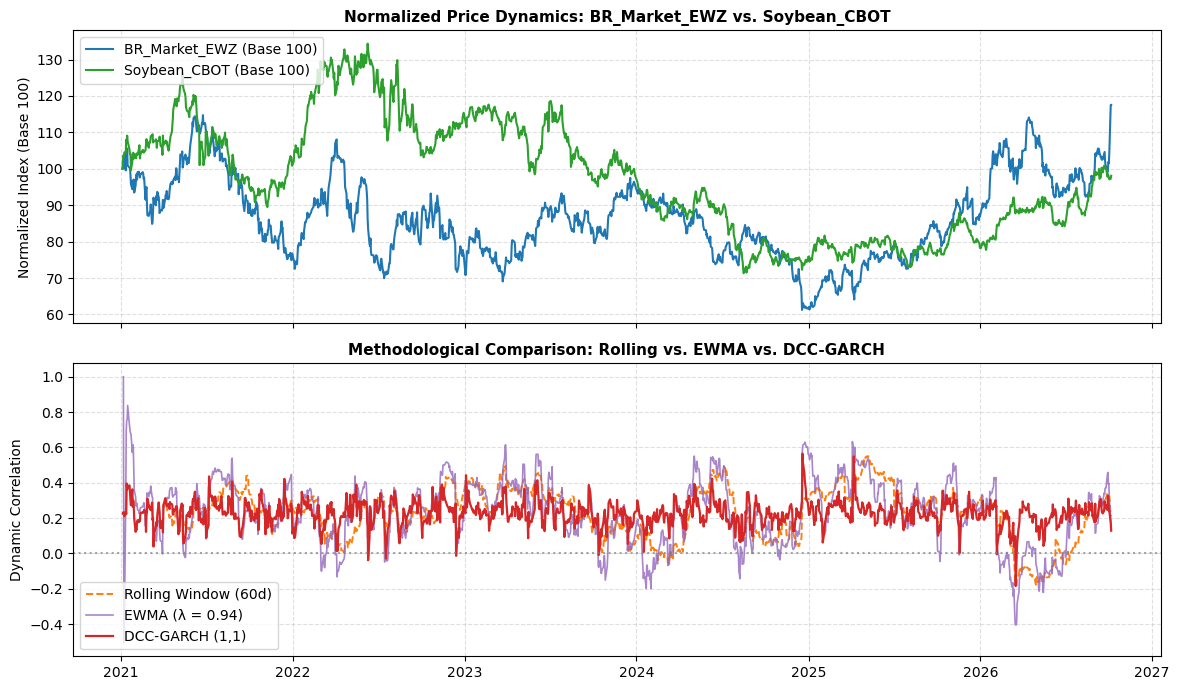

\nProcessing: Impact of global risk-free rate on agricultural cost of capital
Comparative plot successfully saved: 03_treasury10y_vs_soybean_garch.png


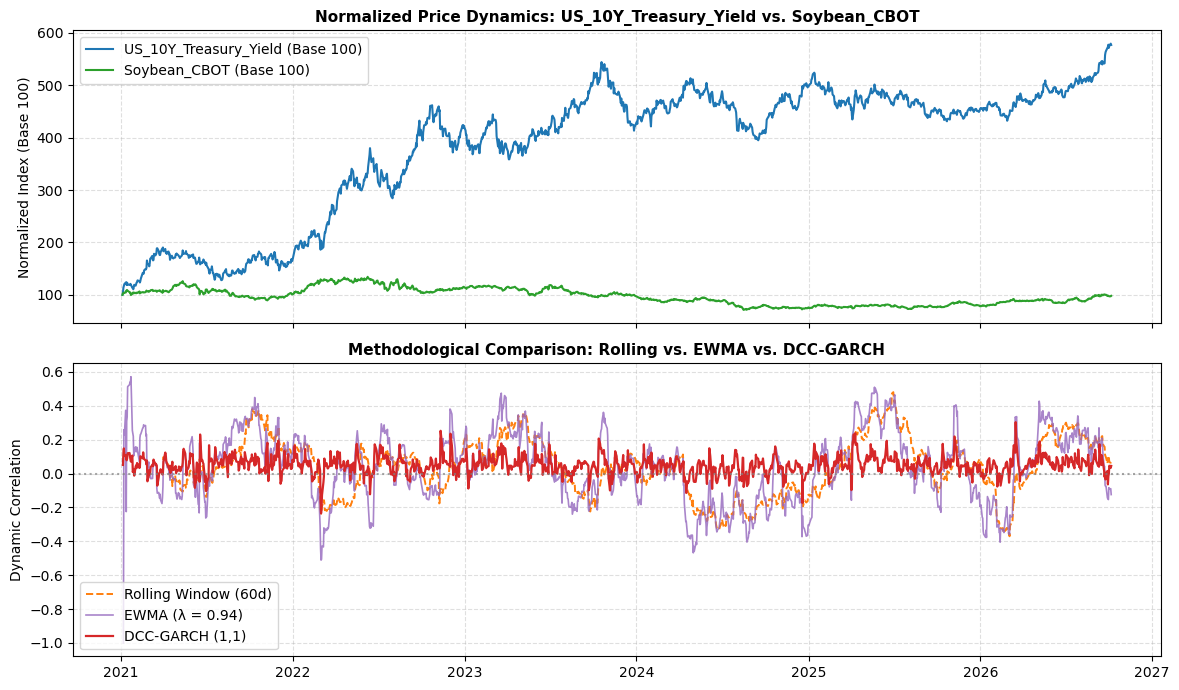

\nProcessing: Global private credit risk appetite vs. Brazilian assets
Comparative plot successfully saved: 04_hyg_vs_ewz_garch.png


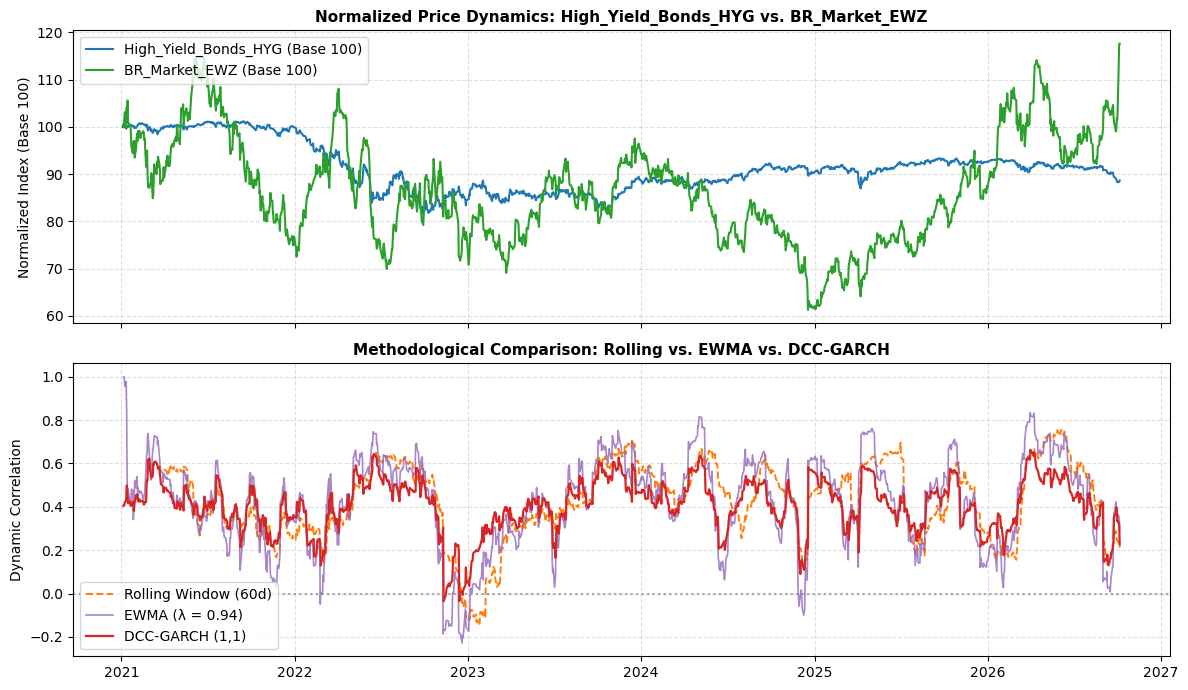

\nProcessing: Logistics/diesel costs vs. grain and biofuel revenue
Comparative plot successfully saved: 05_brent_vs_corn_garch.png


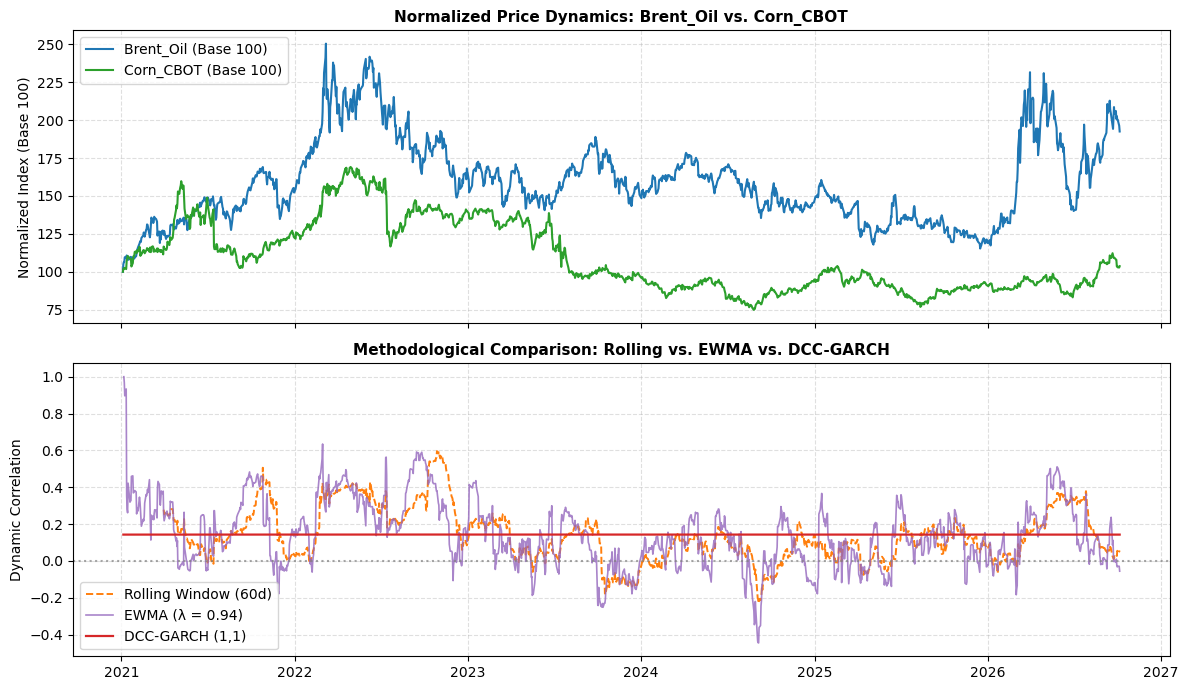

\nProcessing: Natural hedge vs. inflationary pressure from imported inputs
Comparative plot successfully saved: 06_dollar_vs_slce3_garch.png


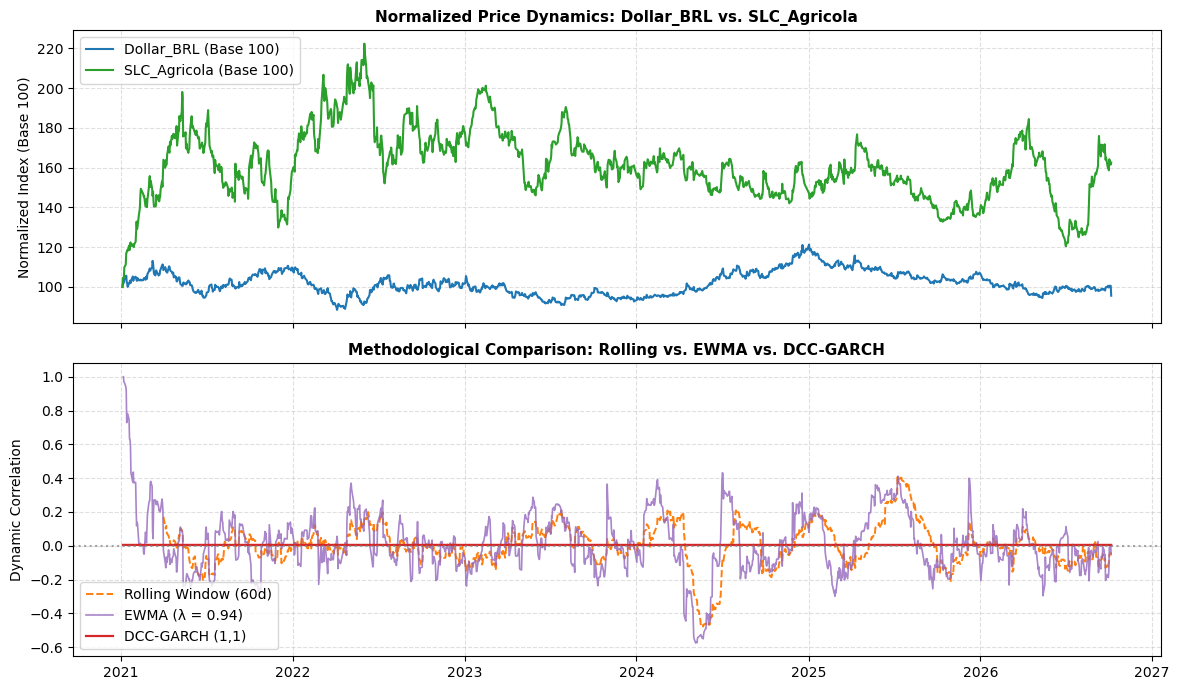

In [4]:
# ==============================================================================
# Parameterized Executions: Multi-Asset Analysis
# ==============================================================================
if __name__ == "__main__":
    
    study_pairs = [
        # --- Block 1: Classic Market Benchmark (Corporate vs. Commodity) ---
        {
            "ticker_a": "PETR4.SA", "label_a": "Petrobras_PN",
            "ticker_b": "BZ=F",     "label_b": "Brent_Oil",
            "output": "01_petr4_vs_brent_garch.png",
            "desc": "International parity pass-through vs. corporate/state risk"
        },
        
        # --- Block 2: Country Risk and Agricultural Demand (Macro vs. Agro) ---
        {
            "ticker_a": "EWZ",      "label_a": "BR_Market_EWZ",
            "ticker_b": "ZS=F",     "label_b": "Soybean_CBOT",
            "output": "02_ewz_vs_soybean_garch.png",
            "desc": "Stock market sensitivity and foreign flow to harvest yields"
        },

        # --- Block 3: Global Funding Cost and Interest Rates (Debt & Funding) ---
        {
            "ticker_a": "^TNX",     "label_a": "US_10Y_Treasury_Yield",
            "ticker_b": "ZS=F",     "label_b": "Soybean_CBOT",
            "output": "03_treasury10y_vs_soybean_garch.png",
            "desc": "Impact of global risk-free rate on agricultural cost of capital"
        },

        # --- Block 4: Corporate Credit Stress / Default (Credit Risk) ---
        {
            "ticker_a": "HYG",      "label_a": "High_Yield_Bonds_HYG",
            "ticker_b": "EWZ",      "label_b": "BR_Market_EWZ",
            "output": "04_hyg_vs_ewz_garch.png",
            "desc": "Global private credit risk appetite vs. Brazilian assets"
        },

        # --- Block 5: Input Cost vs. Selling Price (Operating Margin) ---
        {
            "ticker_a": "BZ=F",     "label_a": "Brent_Oil",
            "ticker_b": "ZC=F",     "label_b": "Corn_CBOT",
            "output": "05_brent_vs_corn_garch.png",
            "desc": "Logistics/diesel costs vs. grain and biofuel revenue"
        },

        # --- Block 6: Currency Risk in Dollarized Rural Production ---
        {
            "ticker_a": "USDBRL=X", "label_a": "Dollar_BRL",
            "ticker_b": "SLCE3.SA", "label_b": "SLC_Agricola",
            "output": "06_dollar_vs_slce3_garch.png",
            "desc": "Natural hedge vs. inflationary pressure from imported inputs"
        }
    ]
    
    # Example execution loop (uncomment to run)
    for pair in study_pairs:
        print(f"\\nProcessing: {pair['desc']}")
        prices_df, returns_df = prepare_returns_pair(
            ticker_a=pair["ticker_a"], 
            ticker_b=pair["ticker_b"], 
            label_a=pair["label_a"], 
            label_b=pair["label_b"]
        )
        plot_models_comparison(
            prices=prices_df, 
            returns=returns_df, 
            label_a=pair["label_a"], 
            label_b=pair["label_b"], 
            output_filename=pair["output"]
         )